In [ ]:
!pip install mne
from google.colab import drive
import os
import mne
import glob
import numpy as np
import pandas as pd
import re
from collections import defaultdict
import joblib
import matplotlib.pyplot as plt
from mne.decoding import CSP
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import seaborn as sns
from scipy.signal import butter, filtfilt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 96.8 MB/s eta 0:00:00


epoching and Bandpass filtering

In [ ]:
drive.mount('/content/drive')
drive_folder = "/content/drive/MyDrive/Brainvision SUBA - 01/session 1 - sub_C00"

subject_file_map = {
    "sub_B95": [f"20250306_B95_000{i}" for i in range(1, 7)],
    "sub_B99": [f"20250314_B99_000{i}" for i in range(1, 7)],
    "sub_C00": [f"20250221_C00_000{i}" for i in range(1, 7)],
}

#(subject, vhdr_path, vmrk_path)
subject_run_files = []

for subject, prefixes in subject_file_map.items():
    for prefix in prefixes:
        vhdr_path = os.path.join(drive_folder, f"{prefix}.vhdr")
        vmrk_path = os.path.join(drive_folder, f"{prefix}.vmrk")

        if os.path.exists(vhdr_path) and os.path.exists(vmrk_path):
            subject_run_files.append((subject, vhdr_path, vmrk_path))
        else:
            print(f"Missing files for {prefix}, skipping.")

# Grouping subjects
subject_run_groups = defaultdict(list)
for subject, vhdr, vmrk in subject_run_files:
    subject_run_groups[subject].append((vhdr, vmrk))



tmin = -3.0
tmax = 7.0

event_id = {
    'S 4': 'Stimulus 4',
    'S 8': 'Stimulus 8',
    'S 16': 'Stimulus 16',
    'S 32': 'Stimulus 32'
}


low_freq = 6.0
high_freq = 42.0

all_epochs = []

epochs_list = list()

for run_idx, (vhdr_file, vmrk_file) in enumerate(subject_run_groups["sub_C00"], start=1):
    print(f"\n--- Processing Run {run_idx} ---")
    print(f"Loading: {vhdr_file}")


    raw = mne.io.read_raw_brainvision(vhdr_file, preload=True)

    raw.filter(low_freq, high_freq, fir_design='firwin')
    print(f"Data filtered with bandpass {low_freq}-{high_freq} Hz")

    # Resampling to 250 Hz
    raw.resample(250, npad="auto")
    print(f"Data resampled to {raw.info['sfreq']} Hz")

    # Extract events from annotations
    events, _ = mne.events_from_annotations(raw)

    # Filter relevant events only
    valid_event_codes = [4, 8, 16, 32]
    event_mask = np.isin(events[:, 2], valid_event_codes)
    events_filtered = events[event_mask]

    epochs = mne.Epochs(raw, events_filtered, event_id=None, tmin=tmin, tmax=tmax,
                        baseline=None, detrend=1, preload=True)
    epochs_list.append(epochs)

    # Extract epoch data and event codes
    epoch_data = epochs.get_data()  # (n_epochs, n_channels, n_times)
    #epochs.save("dir-epo.fif")
    epoch_labels = epochs.events[:, 2]

    # Convert each epoch to a DataFrame
    for epoch_idx in range(epoch_data.shape[0]):
        df_epoch = pd.DataFrame(epoch_data[epoch_idx].T, columns=raw.ch_names)  # (samples x channels)
        df_epoch.insert(0, "Time (s)", epochs.times)
        df_epoch.insert(1, "Run", run_idx)

        # Map event codes to descriptive labels
        event_code = f'S {epoch_labels[epoch_idx]}'
        event_label = event_id.get(event_code, 'Unknown')
        df_epoch["Event Label"] = event_label

        all_epochs.append(df_epoch)

cat_epochs = mne.concatenate_epochs(epochs_list)
cat_epochs.save("foo1-epo.fif", overwrite = True)

# Aggregate all epochs into one DataFrame
full_epoch_df = pd.concat(all_epochs, ignore_index=True)


Mounted at /content/drive

--- Processing Run 1 ---
Loading: /content/drive/MyDrive/Brainvision SUBA - 01/session 1 - sub_C00/20250221_C00_0001.vhdr
Extracting parameters from /content/drive/MyDrive/Brainvision SUBA - 01/session 1 - sub_C00/20250221_C00_0001.vhdr...
Setting channel info structure...


<ipython-input-2-2e43ddbfc5e3>:53: RuntimeWarning: Online software filter detected. Using software filter settings and ignoring hardware values
  raw = mne.io.read_raw_brainvision(vhdr_file, preload=True)
<ipython-input-2-2e43ddbfc5e3>:53: RuntimeWarning: Channels contain different highpass filters. Lowest (weakest) filter setting (0.50 Hz) will be stored.
  raw = mne.io.read_raw_brainvision(vhdr_file, preload=True)


Reading 0 ... 639099  =      0.000 ...   255.640 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 6 - 42 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 6.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 5.00 Hz)
- Upper passband edge: 42.00 Hz
- Upper transition bandwidth: 10.50 Hz (-6 dB cutoff frequency: 47.25 Hz)
- Filter length: 4125 samples (1.650 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Data filtered with bandpass 6.0-42.0 Hz
Data resampled to 250.0 Hz
Used Annotations descriptions: [np.str_('New Segment/'), np.str_('Stimulus/S  4'), np.str_('Stimulus/S  8'), np.str_('Stimulus/S 16'), np.str_('Stimulus/S 32')]
Not setting metadata
61 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 61 events and 2501 original time points ...
0 bad epochs dropped

--- Processing Run 2 ---
Loading: /content/drive/MyDrive/Brainvision SUBA - 01/session 1 - sub_C00/20250221_C00_0002.vhdr
Extracting parameters from /content/drive/MyDrive/Brainvision SUBA - 01/session 1 - sub_C00/20250221_C00_0002.vhdr...
Setting channel info structure...
Reading 0 ... 578899  =      0.000 ...   231.560 secs...


...

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 6 - 42 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 6.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 5.00 Hz)
- Upper passband edge: 42.00 Hz
- Upper transition bandwidth: 10.50 Hz (-6 dB cutoff frequency: 47.25 Hz)
- Filter length: 4125 samples (1.650 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.6s


Data filtered with bandpass 6.0-42.0 Hz
Data resampled to 250.0 Hz
Used Annotations descriptions: [np.str_('New Segment/'), np.str_('Stimulus/S  4'), np.str_('Stimulus/S  8'), np.str_('Stimulus/S 16'), np.str_('Stimulus/S 32')]
Not setting metadata
61 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 61 events and 2501 original time points ...
0 bad epochs dropped


<ipython-input-2-2e43ddbfc5e3>:92: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  cat_epochs = mne.concatenate_epochs(epochs_list)


Not setting metadata
363 matching events found
No baseline correction applied


CSP feature extraction and ensemble modeling

Reading /content/foo1-epo.fif ...
Isotrak not found
    Found the data of interest:
        t =   -3000.00 ...    7000.00 ms
        0 CTF compensation matrices available
Not setting metadata
363 matching events found
No baseline correction applied
0 projection items activated
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Computing rank from data with rank=None
    Using tolerance 49 (2.2e-16 eps * 64 dim * 3.4e+15  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
rf best parameters: {'max_depth': None, 'n_estimators': 100}
rf best score: 0.741
svm best parameters: {'C': 10, 'kernel': 'rbf'}
svm best score: 0.751
lr best parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
lr best score: 0.761
Ensemble Classification Accuracy: 79.17%


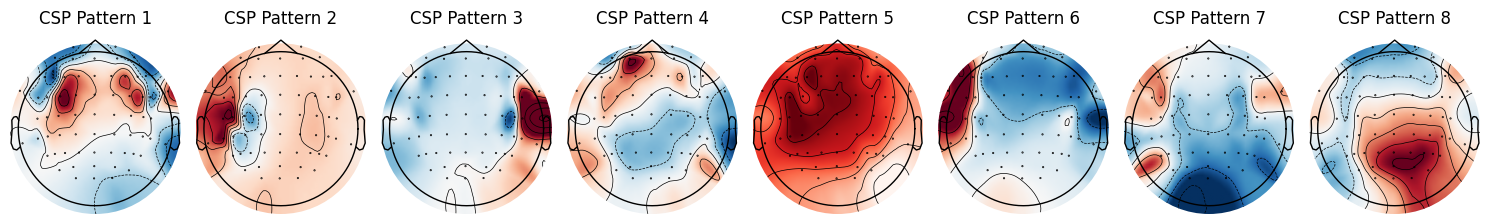

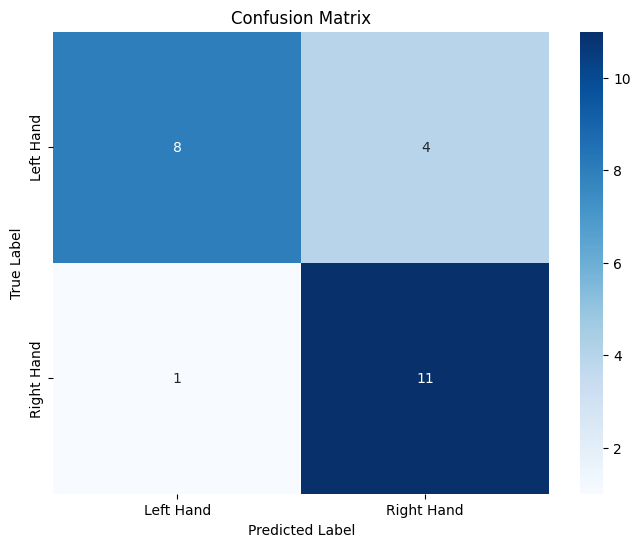


Final Classification Metrics:
Accuracy: 79.17%
Precision: 73.33%
Recall: 91.67%

Models saved successfully: csp_model1.pkl & classifier1.pkl


In [ ]:
def extractCat(indicesFile):
    colnames = ['trial', 'marker']
    data = pd.read_csv(indicesFile, names=colnames)
    np.array([1 if marker == 8 else 0 for marker in data.marker if marker == 8 or marker == 16])


def load_epochs(file_path):
    """Loads epochs and assigns a default electrode montage."""
    epochs = mne.read_epochs(file_path, preload=True)
    epochs.pick_types(eeg=True)
    epochs.drop_channels(["EMG_right", "EMG_left"])
    epochs.set_montage("standard_1020", on_missing="ignore")
    epochs.set_montage("standard_1020")
    return epochs[np.isin(epochs.events[:, 2], [8, 16])]

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs  # Nyquist frequency
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=-1)

def preprocess_epochs(epochs):
    """Enhanced preprocessing of EEG epochs."""
    # Apply bandpass filter (8-30 Hz for motor imagery)
    fs = epochs.info['sfreq']
    data = epochs.get_data()
    filtered_data = np.array([bandpass_filter(epoch, 8, 30, fs) for epoch in data])

    # Standardize each channel
    scaler = StandardScaler()
    X = np.array([scaler.fit_transform(epoch.T).T for epoch in filtered_data])

    # Extract features
    y = np.array([1 if event == 8 else 0 for event in epochs.events[:, 2]])
    return X, y

def apply_csp(X, y):
    """Applies Common Spatial Patterns (CSP) with cross-validation."""
    csp = CSP(n_components=8, reg=None, log=True, norm_trace=False)
    X_csp = csp.fit_transform(X, y)
    return X_csp, csp

def train_classifier(X, y):
    """Trains an ensemble classifier with hyperparameter tuning."""
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Define base classifiers
    rf = RandomForestClassifier(random_state=42)
    svm = SVC(probability=True, random_state=42)
    lr = LogisticRegression(random_state=42, solver='liblinear')  # Changed solver to liblinear

    # Define parameter grids for GridSearchCV
    param_grids = {
        'rf': {'n_estimators': [100, 200, 300], 'max_depth': [None, 10, 20]},
        'svm': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']},
        'lr': {'C': [0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}  # Modified LR parameters
    }

    # Perform GridSearchCV for each classifier
    best_estimators = {}
    for name, clf, param_grid in [('rf', rf, param_grids['rf']),
                                 ('svm', svm, param_grids['svm']),
                                 ('lr', lr, param_grids['lr'])]:
        grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        best_estimators[name] = grid_search.best_estimator_
        print(f"{name} best parameters: {grid_search.best_params_}")
        print(f"{name} best score: {grid_search.best_score_:.3f}")

    # Create voting classifier
    voting_clf = VotingClassifier(
        estimators=[('rf', best_estimators['rf']),
                   ('svm', best_estimators['svm']),
                   ('lr', best_estimators['lr'])],
        voting='soft'
    )

    # Train voting classifier
    voting_clf.fit(X_train, y_train)
    y_pred = voting_clf.predict(X_test)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    print(f'Ensemble Classification Accuracy: {acc * 100:.2f}%')

    return voting_clf, X_train, X_test, y_train, y_test, y_pred

def plot_csp_patterns(csp, epochs):
    """Plots CSP patterns for EEG channels."""
    fig, axes = plt.subplots(1, 8, figsize=(15, 8))
    for i, ax in enumerate(axes):
        mne.viz.plot_topomap(csp.patterns_[i], epochs.info, axes=ax, show=False)
        ax.set_title(f'CSP Pattern {i+1}')
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_test, y_pred):
    """Plots the confusion matrix."""
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Left Hand', 'Right Hand'],
                yticklabels=['Left Hand', 'Right Hand'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

# === Pipeline Execution ===
file_path = '/content/foo1-epo.fif'
epochs = load_epochs(file_path)
X, y = preprocess_epochs(epochs)
X_csp, csp = apply_csp(X, y)
clf, X_train, X_test, y_train, y_test, y_pred = train_classifier(X_csp, y)

# === Plot Results ===
plot_csp_patterns(csp, epochs)
plot_confusion_matrix(y_test, y_pred)

# === Calculate and Print Metrics ===
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f'\nFinal Classification Metrics:')
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')

# === Save Trained Models ===
joblib.dump(csp, "csp_model1.pkl")
joblib.dump(clf, "classifier1.pkl")
print("\nModels saved successfully: csp_model1.pkl & classifier1.pkl")

